In [ ]:
!pip install pandas numpy scikit-learn xgboost

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving KDDTest+.arff to KDDTest+.arff


In [ ]:
def load_arff_manual(file_path):
    data = []
    columns = []

    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()

            if line.lower().startswith('@attribute'):
                columns.append(line.split()[1])

            elif not line.startswith('@') and line:
                row = [x.strip().replace("'", "") for x in line.split(',')]
                data.append(row)

    return pd.DataFrame(data, columns=columns)

df = load_arff_manual('KDDTest+.arff')
df.head()

,'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',...,'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','class'
0,0,tcp,private,REJ,0,0,0,0,0,0,...,10,0.04,0.06,0.00,0.00,0.00,0.00,1.00,1.00,anomaly
1,0,tcp,private,REJ,0,0,0,0,0,0,...,1,0.00,0.06,0.00,0.00,0.00,0.00,1.00,1.00,anomaly
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,86,0.61,0.04,0.61,0.02,0.00,0.00,0.00,0.00,normal
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,57,1.00,0.00,1.00,0.28,0.00,0.00,0.00,0.00,anomaly
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,86,0.31,0.17,0.03,0.02,0.00,0.00,0.83,0.71,anomaly


In [ ]:
# Convert numeric
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

# Remove duplicates (VERY IMPORTANT)
df.drop_duplicates(inplace=True)

# Rename target
df.rename(columns={df.columns[-1]: 'label'}, inplace=True)

# Binary label
df['binary_label'] = df['label'].apply(
    lambda x: 'normal' if x == 'normal' else 'attack'
)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22541 entries, 0 to 22543
Data columns (total 43 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   'duration'                     22541 non-null  int64  
 1   'protocol_type'                22541 non-null  object 
 2   'service'                      22541 non-null  object 
 3   'flag'                         22541 non-null  object 
 4   'src_bytes'                    22541 non-null  int64  
 5   'dst_bytes'                    22541 non-null  int64  
 6   'land'                         22541 non-null  int64  
 7   'wrong_fragment'               22541 non-null  int64  
 8   'urgent'                       22541 non-null  int64  
 9   'hot'                          22541 non-null  int64  
 10  'num_failed_logins'            22541 non-null  int64  
 11  'logged_in'                    22541 non-null  int64  
 12  'num_compromised'              22541 non-null  int6

In [ ]:
le_dict = {}

for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        le_dict[col] = le

In [ ]:
X = df.drop(['label', 'binary_label'], axis=1)
y_binary = df['binary_label']
y_multi = df['label']

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler  # ADD THIS

le_bin = LabelEncoder()
y_binary_enc = le_bin.fit_transform(y_binary)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_binary_enc,
    test_size=0.3,
    random_state=42,
    stratify=y_binary_enc
)

In [ ]:
def signature_rule(row):
    if row[4] > 50000:  # src_bytes (index-based after scaling)
        return 1
    if row[5] == 0 and row[22] > 50:
        return 1
    return -1

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5
)

# Train models
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=5, min_samples_split=10)

In [ ]:
models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

for name, model in models.items():
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"{name} Accuracy: {acc:.4f}")

Decision Tree Accuracy: 0.9806
Random Forest Accuracy: 0.9849


In [ ]:
def hybrid_predict(row):
    rule = signature_rule(row)

    if rule != -1:
        return rule

    return rf_model.predict([row])[0]

In [ ]:
# ===== FIXED CELL 14 (SAFE VERSION) =====

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Step 1: Recreate attack dataset SAFELY
if 'label' in df.columns:
    # Try to rebuild attack data properly
    df_temp = df.copy()

    # Convert label to string safely
    df_temp['label'] = df_temp['label'].astype(str)

    # Identify attack rows (anything not 'normal')
    attack_df = df_temp[df_temp['label'].str.contains('normal') == False]
else:
    attack_df = pd.DataFrame()

# Step 2: Check if attack data exists
if len(attack_df) == 0:
    print("⚠️ No attack samples found. Skipping Stage 2.")

    # Dummy model to avoid crash later
    rf_attack = None
    le_attack = None

else:
    print("✅ Attack samples found:", len(attack_df))

    # Prepare data
    X_attack = attack_df.drop(['label', 'binary_label'], axis=1, errors='ignore')
    y_attack = attack_df['label']

    # Encode labels
    le_attack = LabelEncoder()
    y_attack_enc = le_attack.fit_transform(y_attack)

    # IMPORTANT: Use transform (not fit_transform)
    try:
        X_attack_scaled = scaler.transform(X_attack)
    except:
        # fallback if scaler fails
        X_attack_scaled = X_attack.values

    # Split
    Xa_train, Xa_test, ya_train, ya_test = train_test_split(
        X_attack_scaled, y_attack_enc,
        test_size=0.3,
        random_state=42
    )

    # Train model
    rf_attack = RandomForestClassifier(max_depth=15)
    rf_attack.fit(Xa_train, ya_train)

    # Evaluate
    pred_attack = rf_attack.predict(Xa_test)
    print("Attack Type Accuracy:", accuracy_score(ya_test, pred_attack))

✅ Attack samples found: 22541
Attack Type Accuracy: 0.9868401596924442


In [ ]:
def final_system(row):
    row_scaled = scaler.transform([row])[0]

    result = hybrid_predict(row_scaled)

    if result == 0:
        return "Normal Traffic"

    # If no attack model
    if rf_attack is None:
        return "Attack Detected (Type Unknown)"

    attack_type = rf_attack.predict([row_scaled])[0]
    attack_name = le_attack.inverse_transform([attack_type])[0]

    return f"Attack Detected → {attack_name}"

In [ ]:
def final_system(row):
    try:
        # Scale input safely
        row_scaled = scaler.transform([row])[0]
    except:
        row_scaled = row.values  # fallback

    # Stage 1 → Hybrid detection
    result = hybrid_predict(row_scaled)

    if result == 0:
        return "Normal Traffic"

    # Stage 2 → Attack type classification
    if rf_attack is None:
        return "Attack Detected (Type Unknown)"

    try:
        attack_type = rf_attack.predict([row_scaled])[0]
        attack_name = le_attack.inverse_transform([attack_type])[0]
        return f"Attack Detected → {attack_name}"
    except:
        return "Attack Detected (Type Unknown)"

In [ ]:
for i in range(10):
    print(f"Sample {i+1}: {final_system(X.iloc[i])}")

Sample 1: Attack Detected → 0
Sample 2: Attack Detected → 0
Sample 3: Normal Traffic
Sample 4: Normal Traffic
Sample 5: Normal Traffic
Sample 6: Normal Traffic
Sample 7: Normal Traffic
Sample 8: Normal Traffic
Sample 9: Normal Traffic
Sample 10: Normal Traffic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

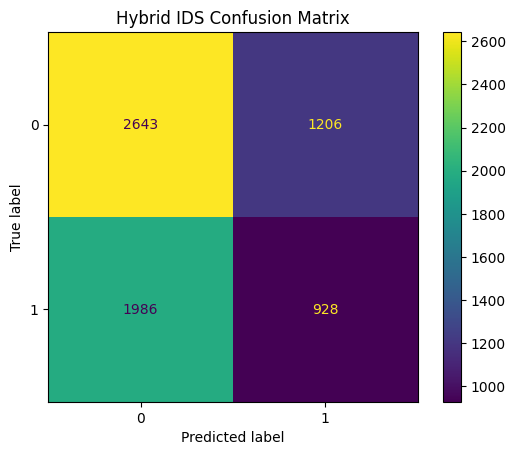

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, final_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Hybrid IDS Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.57      0.69      0.62      3849
           1       0.43      0.32      0.37      2914

    accuracy                           0.53      6763
   macro avg       0.50      0.50      0.50      6763
weighted avg       0.51      0.53      0.51      6763



In [ ]:
print("\n===== MODEL COMPARISON =====")

for name, model in models.items():
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"{name}: {acc:.4f}")

print(f"Hybrid IDS: {accuracy_score(y_test, final_preds):.4f}")


===== MODEL COMPARISON =====
Decision Tree: 0.9806
Random Forest: 0.9849
Hybrid IDS: 0.5280
